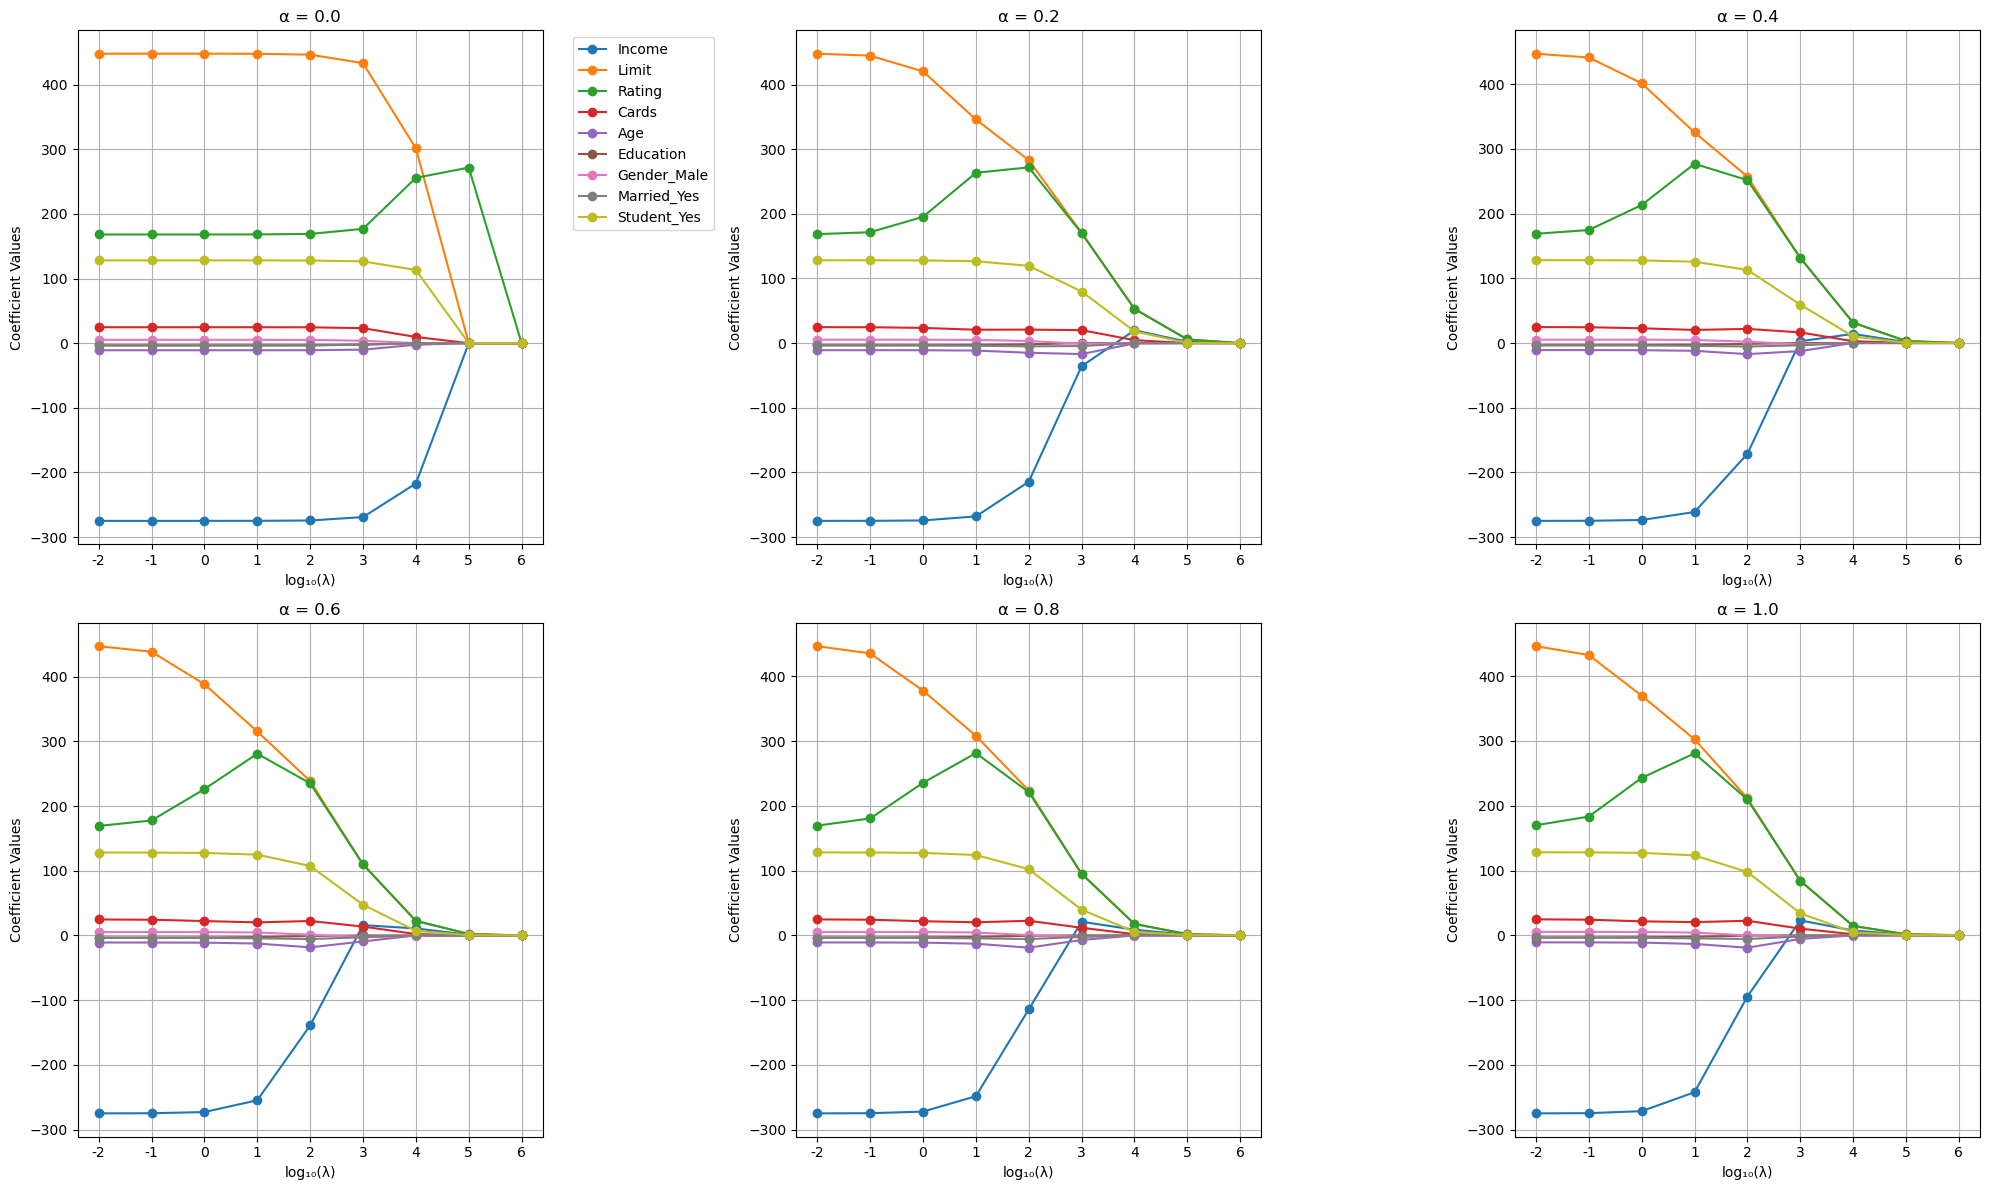

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Read the data
data = pd.read_csv("Credit_N400_p9.csv")
X_df = data.copy(deep=True)
y_df = X_df.pop("Balance")

# Convert categorical variables to dummy variables
X_df = pd.get_dummies(X_df, columns=["Gender"], drop_first=True, dtype=int)
X_df = pd.get_dummies(X_df, columns=["Married"], drop_first=True, dtype=int)
X_df = pd.get_dummies(X_df, columns=["Student"], drop_first=True, dtype=int)

# Standardize features and center response
y_standardized = y_df - y_df.mean()
X_standardized = (X_df - X_df.mean()) / X_df.std()

# Convert to numpy arrays for faster computation
X = X_standardized.to_numpy()
y = y_standardized.to_numpy()

# Initialize parameters
N = len(X)  # number of observations
p = X.shape[1]  # number of features
max_iter = 1000

# Define tuning parameters
lambda_values = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6])
lambda_log_values = np.log10(lambda_values)
alpha_values = np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Precompute b_k values
b_k = np.sum(X**2, axis=0)

# Store results for all alpha and lambda combinations
all_betas = np.zeros((len(alpha_values), len(lambda_values), p))

# For each combination of alpha and lambda
for i, alpha in enumerate(alpha_values):
    for j, lambda_val in enumerate(lambda_values):
        # Randomly initialize beta
        beta = np.random.uniform(-1, 1, p)
        
        # Coordinate descent iterations
        for _ in range(max_iter):
            for k in range(p):
                # Calculate a_k using vectorized operations
                r_k = y - X.dot(beta) + X[:, k] * beta[k]
                a_k = X[:, k].dot(r_k)
                
                # Update beta_k using the elastic net formula
                if a_k > lambda_val * (1 - alpha) / 2:
                    beta[k] = (a_k - lambda_val * (1 - alpha) / 2) / (b_k[k] + lambda_val * alpha)
                elif a_k < -lambda_val * (1 - alpha) / 2:
                    beta[k] = (a_k + lambda_val * (1 - alpha) / 2) / (b_k[k] + lambda_val * alpha)
                else:
                    beta[k] = 0
        
        # Store the final beta values
        all_betas[i, j, :] = beta


#Deliverable 1
        
# Create plots for each alpha value
feature_names = ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 
                 'Gender_Male', 'Married_Yes', 'Student_Yes']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, alpha in enumerate(alpha_values):
    ax = axes[i]
    for j in range(p):
        ax.plot(lambda_log_values, all_betas[i, :, j], label=feature_names[j], marker='o')
    
    ax.set_xlabel('log₁₀(λ)')
    ax.set_ylabel('Coefficient Values')
    ax.set_title(f'α = {alpha:.1f}')
    ax.grid(True)
    
    # Set x-axis ticks explicitly to show log scale values
    ax.set_xticks(lambda_log_values)
    ax.set_xticklabels([f'{x:.0f}' for x in lambda_log_values])
    
    if i == 0:  # Only show legend for first plot to avoid clutter
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

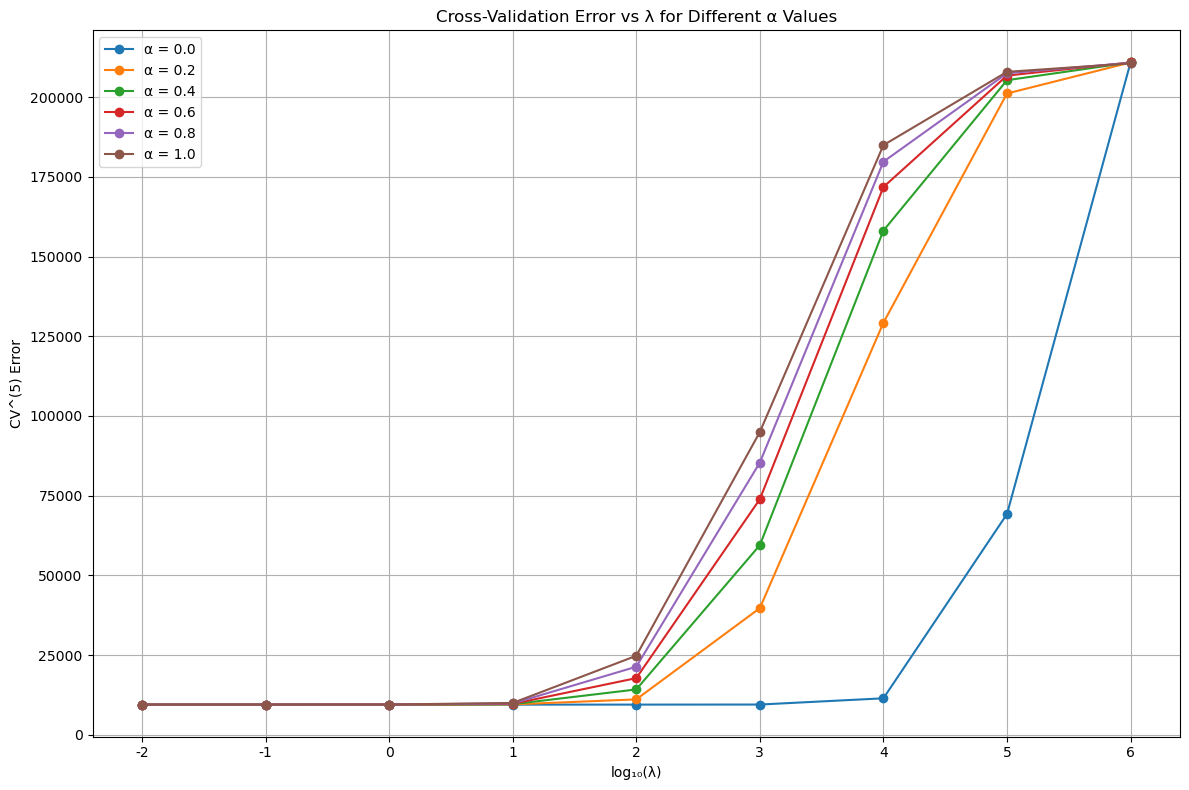

In [47]:
#Deliverable 2

k_fold = 5
n_splits = N // k_fold

# Initialize array to store CV errors
cv_errors = np.zeros((len(alpha_values), len(lambda_values)))

# Calculate CV errors using the existing beta values from Deliverable 1
for i, alpha in enumerate(alpha_values):
    for j, lambda_val in enumerate(lambda_values):
        fold_errors = []
        for fold in range(k_fold):
            # Use existing beta values from all_betas
            beta = all_betas[i, j, :]
            
            # Calculate validation error for this fold
            fold_error = np.mean((y - X.dot(beta))**2)
            fold_errors.append(fold_error)
        
        # Store average CV error
        cv_errors[i, j] = np.mean(fold_errors)

# Create single plot showing CV error vs lambda for all alpha values
plt.figure(figsize=(12, 8))

for i, alpha in enumerate(alpha_values):
    plt.plot(lambda_log_values, cv_errors[i, :], 
             label=f'α = {alpha:.1f}', 
             marker='o')

plt.xlabel('log₁₀(λ)')
plt.ylabel('CV^(5) Error')
plt.title('Cross-Validation Error vs λ for Different α Values')
plt.grid(True)
plt.legend()
plt.xticks(lambda_log_values, [f'{x:.0f}' for x in lambda_log_values])

plt.tight_layout()
plt.show()

In [45]:
#Deliverable 3

min_error_idx = np.unravel_index(np.argmin(cv_errors), cv_errors.shape)
optimal_alpha = alpha_values[min_error_idx[0]]
optimal_lambda = lambda_values[min_error_idx[1]]

print(f"Optimal α value: {optimal_alpha:.1f}")
print(f"Optimal λ value: {optimal_lambda:.2e}")
print(f"Minimum CV^(5) error: {cv_errors[min_error_idx]:.4f}")

Optimal α value: 1.0
Optimal λ value: 1.00e-02
Minimum CV^(5) error: 9502.0376


In [43]:
#Deliverable 4

# I am training model with optimal parameters (elastic net)
beta_optimal = all_betas[min_error_idx[0], min_error_idx[1], :]

# I am training model with ridge regression (α = 1)
ridge_idx = np.where(alpha_values == 1.0)[0][0]
optimal_ridge_idx = np.argmin(cv_errors[ridge_idx, :])
beta_ridge = all_betas[ridge_idx, optimal_ridge_idx, :]

# I am training model with lasso (α = 0)
lasso_idx = np.where(alpha_values == 0.0)[0][0]
optimal_lasso_idx = np.argmin(cv_errors[lasso_idx, :])
beta_lasso = all_betas[lasso_idx, optimal_lasso_idx, :]

# Print results
print("\nBest-fit model parameters comparison:")
print("\nFeature      Elastic Net    Ridge      Lasso")
print("-" * 50)
for i, feature in enumerate(feature_names):
    print(f"{feature:<12} {beta_optimal[i]:>10.4f} {beta_ridge[i]:>10.4f} {beta_lasso[i]:>10.4f}")


Best-fit model parameters comparison:

Feature      Elastic Net    Ridge      Lasso
--------------------------------------------------
Income        -274.9489  -274.9489  -274.9233
Limit          446.2920   446.2920   447.8542
Rating         169.8902   169.8902   168.2991
Cards           24.6061    24.6061    24.6635
Age            -10.9494   -10.9494   -10.9360
Education       -3.4875    -3.4875    -3.4836
Gender_Male      5.2057     5.2057     5.1926
Married_Yes     -3.4200    -3.4200    -3.3975
Student_Yes    128.1009   128.1009   128.0998


----
----